In [34]:
import sys, json, random, math
from datetime import datetime
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import builtins
import shutil

sys.path.insert(0, "..")
from bridgingNorms import CommunityNormAnalyzer, NotEnoughSamplesError

In [26]:
COMMUNITY_A = "t5_2rnve"
COMMUNITY_B = "t5_3onkg"
DATA_FILE   = "../data_training_selected_clusters_comments_and_rules.csv"
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = Path(f"{timestamp}")

OUTPUT_DIR.mkdir(exist_ok=True)

In [29]:
analyzer = CommunityNormAnalyzer()
df = analyzer.load_data(DATA_FILE, min_samp=10)
df = df[df['community_id'].isin([COMMUNITY_A, COMMUNITY_B])]

for cid in [COMMUNITY_A, COMMUNITY_B]:
    n = len(df[df['community_id'] == cid])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 973.16it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


label
non_violation    17506
violation        15460
Name: count, dtype: int64
str
0         violation
1     non_violation
2     non_violation
3     non_violation
4         violation
5     non_violation
6     non_violation
7         violation
8     non_violation
9         violation
10        violation
11        violation
12        violation
13    non_violation
14    non_violation
15        violation
16        violation
17        violation
18        violation
19        violation
Name: label, dtype: str
Per-community counts (before filtering):
              violations  non_violations
community_id                            
t5_10qj6b             61              91
t5_10to4u              4               6
t5_1136aw              2               3
t5_11d8d1              2               0
t5_12n5pd              7              10
...                  ...             ...
t5_xa0lk               1               1
t5_xmk1t               2               2
t5_xpfq5               2               2
t5

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 953.71it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


label
non_violation    17506
violation        15460
Name: count, dtype: int64
str
0         violation
1     non_violation
2     non_violation
3     non_violation
4         violation
5     non_violation
6     non_violation
7         violation
8     non_violation
9         violation
10        violation
11        violation
12        violation
13    non_violation
14    non_violation
15        violation
16        violation
17        violation
18        violation
19        violation
Name: label, dtype: str
Per-community counts (before filtering):
              violations  non_violations
community_id                            
t5_10qj6b             61              91
t5_10to4u              4               6
t5_1136aw              2               3
t5_11d8d1              2               0
t5_12n5pd              7              10
...                  ...             ...
t5_xa0lk               1               1
t5_xmk1t               2               2
t5_xpfq5               2               2
t5

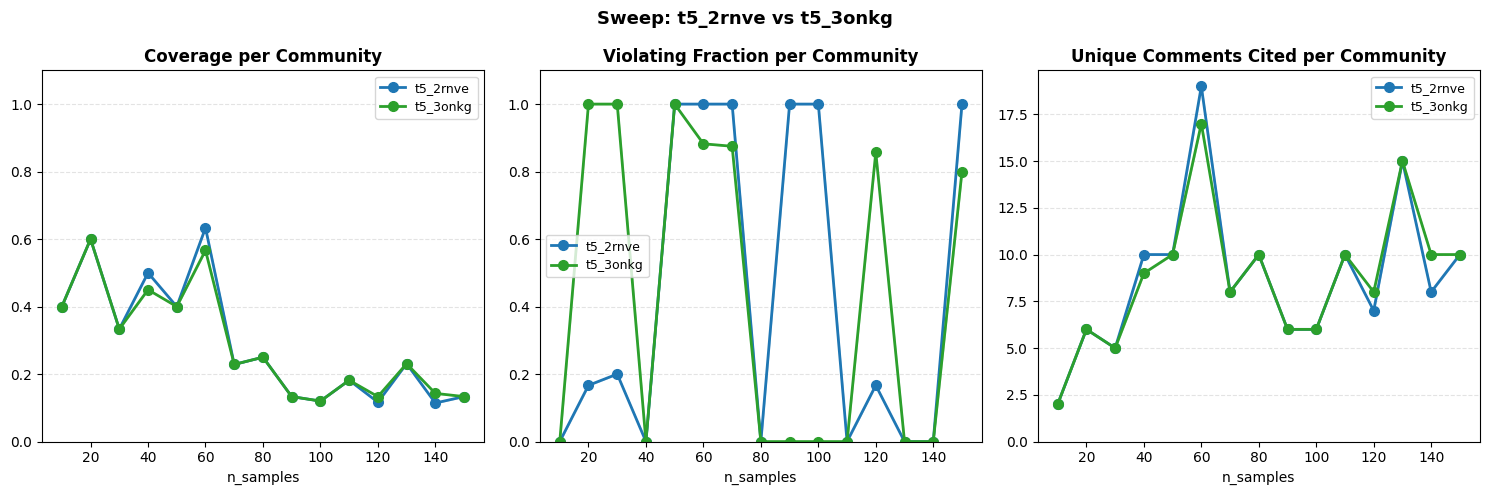

Sweep plot → 20260526_012123/sweep_20260526_012123.png
Sweep data → 20260526_012123/sweep_records_20260526_012123.json


In [35]:
COMMUNITY_A = "t5_2rnve"
COMMUNITY_B = "t5_3onkg"
DATA_FILE   = "../data_training_selected_clusters_comments_and_rules.csv"
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = Path(f"{timestamp}")

OUTPUT_DIR.mkdir(exist_ok=True)

analyzer = CommunityNormAnalyzer()
df = analyzer.load_data(DATA_FILE, min_samp=10)
df = df[df['community_id'].isin([COMMUNITY_A, COMMUNITY_B])]

for cid in [COMMUNITY_A, COMMUNITY_B]:
    n = len(df[df['community_id'] == cid])


RUN_SWEEP    = True
SWEEP_SIZES  = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
SWEEP_TRIALS = 1
if RUN_SWEEP:
    sweep_records = []
    _real_input = builtins.input
    builtins.input = lambda _prompt="": "sweep"

    try:
        for n in SWEEP_SIZES:
            for trial in range(SWEEP_TRIALS):
                random.seed(trial * 100)
                print(f"n={n}, trial={trial+1}/{SWEEP_TRIALS}")
                try:
                    r = analyzer.run_task(df, COMMUNITY_A, COMMUNITY_B,
                                         task_name="task2", n_samples=n, verbose=False)

                    if r and "error" not in r:
                        run_log_path = OUTPUT_DIR / "task2_run_log_all.json"
                        src = Path("task2_run_log.json")
                        if src.exists():
                            with open(src) as f:
                                run_log = json.load(f)
                            src.unlink()  # delete the original
                            if run_log_path.exists():
                                with open(run_log_path) as f:
                                    all_logs = json.load(f)
                            else:
                                all_logs = []
                            all_logs.append(run_log)
                            with open(run_log_path, 'w') as f:
                                json.dump(all_logs, f, indent=2, ensure_ascii=False)
                        rec = r['metrics'].copy()
                        rec['n_samples'] = n

                        # Per-community violating fractions
                        id_to_status = {c[0]: c[3] for c in r['input_comments']}
                        id_to_comm   = {c[0]: c[2] for c in r['input_comments']}
                        parsed = r['norms']

                        def vf_for(ids, community):
                            cited = [i for i in ids if id_to_comm.get(i) == community]
                            if not cited: return 0.0
                            return sum(1 for i in cited if id_to_status.get(i) == 'violation') / len(cited)

                        rec['violating_fraction_a'] = vf_for(parsed['comm_a_ids'], COMMUNITY_A)
                        rec['violating_fraction_b'] = vf_for(parsed['comm_b_ids'], COMMUNITY_B)
                        sweep_records.append(rec)
                        norms_log_path = OUTPUT_DIR / "norm_definitions_all.json"
                        # Load existing if present
                        if norms_log_path.exists():
                            with open(norms_log_path) as f:
                                all_norms = json.load(f)
                        else:
                            all_norms = []

                        all_norms.append({
                            "n_samples": n,
                            "trial": trial,
                            "community_a": COMMUNITY_A,
                            "community_b": COMMUNITY_B,
                            "norms": {
                                COMMUNITY_A: {"description": parsed['comm_a_desc'], "cited_ids": parsed['comm_a_ids']},
                                COMMUNITY_B: {"description": parsed['comm_b_desc'], "cited_ids": parsed['comm_b_ids']}
                            }
                        })

                        with open(norms_log_path, 'w') as f:
                            json.dump(all_norms, f, indent=2, ensure_ascii=False)
                        print(f"  cov={rec.get('coverage',0):.3f}  vf_a={rec['violating_fraction_a']:.3f}  vf_b={rec['violating_fraction_b']:.3f}")
                except NotEnoughSamplesError as e:
                    print(f"  Skipped: {e} — stopping sweep, not enough samples beyond n={n}")
                    SWEEP_SIZES = [s for s in SWEEP_SIZES if s < n]
                    break
    finally:
        builtins.input = _real_input

    # Sweep plots
    palette = plt.cm.tab10.colors
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Sweep: {COMMUNITY_A} vs {COMMUNITY_B}", fontsize=13, fontweight='bold')

    # Coverage — one line per community
    ax = axes[0]
    for label, raw_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        for n in SWEEP_SIZES:
            vals = [r[raw_metric] / (n/2) for r in sweep_records if r['n_samples'] == n and raw_metric in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Coverage per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(0, 1.1); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)
 # Violating fraction — one line per community
    ax = axes[1]
    for label, a_metric, b_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', 'violating_fraction_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', 'violating_fraction_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        vf_key = 'violating_fraction_a' if label == COMMUNITY_A else 'violating_fraction_b'
        for n in SWEEP_SIZES:
            vals = [r[vf_key] for r in sweep_records if r['n_samples'] == n and vf_key in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Violating Fraction per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(0, 1.1); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)

    # Unique comments — one line per community
    ax = axes[2]
    for label, raw_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        for n in SWEEP_SIZES:
            vals = [r[raw_metric] for r in sweep_records if r['n_samples'] == n and raw_metric in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Unique Comments Cited per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(bottom=0); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)

    plt.tight_layout()
    sweep_path = OUTPUT_DIR / f"sweep_{timestamp}.png"
    fig.savefig(sweep_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Sweep plot → {sweep_path}")

    sweep_json = OUTPUT_DIR / f"sweep_records_{timestamp}.json"
    with open(sweep_json, 'w') as f:
        json.dump(sweep_records, f, indent=2, ensure_ascii=False)
    print(f"Sweep data → {sweep_json}")
else:
    print("Sweep skipped — set RUN_SWEEP = True to enable.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1758.52it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


label
non_violation    17506
violation        15460
Name: count, dtype: int64
str
0         violation
1     non_violation
2     non_violation
3     non_violation
4         violation
5     non_violation
6     non_violation
7         violation
8     non_violation
9         violation
10        violation
11        violation
12        violation
13    non_violation
14    non_violation
15        violation
16        violation
17        violation
18        violation
19        violation
Name: label, dtype: str
Per-community counts (before filtering):
              violations  non_violations
community_id                            
t5_10qj6b             61              91
t5_10to4u              4               6
t5_1136aw              2               3
t5_11d8d1              2               0
t5_12n5pd              7              10
...                  ...             ...
t5_xa0lk               1               1
t5_xmk1t               2               2
t5_xpfq5               2               2
t5

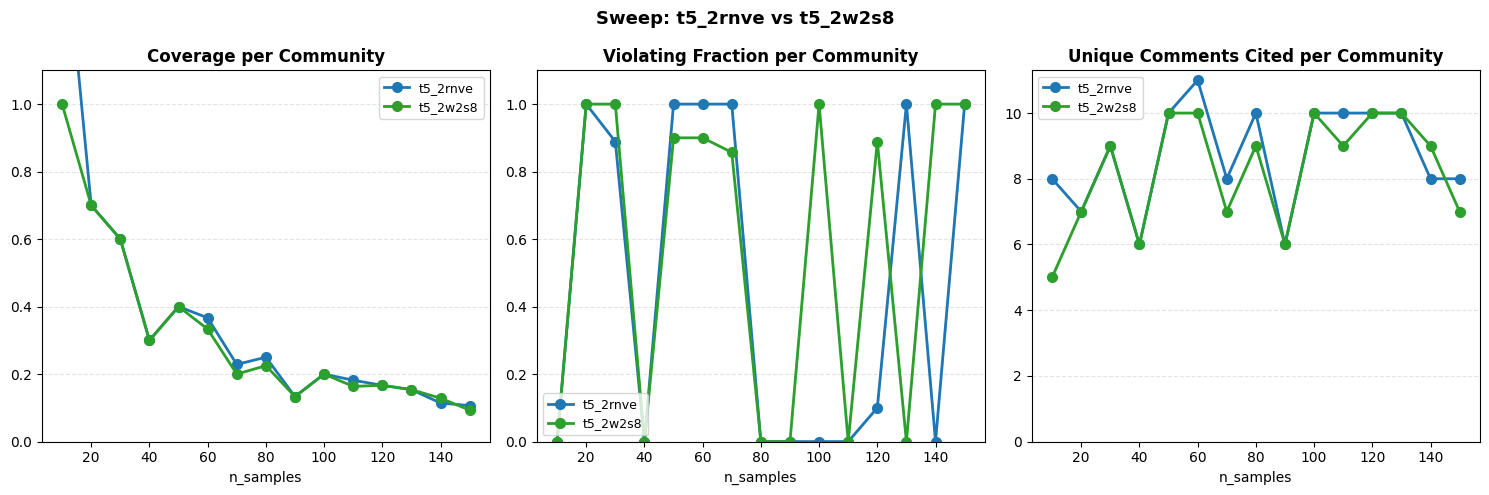

Sweep plot → 20260526_012508/sweep_20260526_012508.png
Sweep data → 20260526_012508/sweep_records_20260526_012508.json


In [36]:
COMMUNITY_A = "t5_2rnve"
COMMUNITY_B = "t5_2w2s8"
DATA_FILE   = "../data_training_selected_clusters_comments_and_rules.csv"
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = Path(f"{timestamp}")

OUTPUT_DIR.mkdir(exist_ok=True)

analyzer = CommunityNormAnalyzer()
df = analyzer.load_data(DATA_FILE, min_samp=10)
df = df[df['community_id'].isin([COMMUNITY_A, COMMUNITY_B])]

for cid in [COMMUNITY_A, COMMUNITY_B]:
    n = len(df[df['community_id'] == cid])


RUN_SWEEP    = True
SWEEP_SIZES  = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
SWEEP_TRIALS = 1
if RUN_SWEEP:
    sweep_records = []
    _real_input = builtins.input
    builtins.input = lambda _prompt="": "sweep"

    try:
        for n in SWEEP_SIZES:
            for trial in range(SWEEP_TRIALS):
                random.seed(trial * 100)
                print(f"n={n}, trial={trial+1}/{SWEEP_TRIALS}")
                try:
                    r = analyzer.run_task(df, COMMUNITY_A, COMMUNITY_B,
                                         task_name="task2", n_samples=n, verbose=False)

                    if r and "error" not in r:
                        run_log_path = OUTPUT_DIR / "task2_run_log_all.json"
                        src = Path("task2_run_log.json")
                        if src.exists():
                            with open(src) as f:
                                run_log = json.load(f)
                            src.unlink()  # delete the original
                            if run_log_path.exists():
                                with open(run_log_path) as f:
                                    all_logs = json.load(f)
                            else:
                                all_logs = []
                            all_logs.append(run_log)
                            with open(run_log_path, 'w') as f:
                                json.dump(all_logs, f, indent=2, ensure_ascii=False)
                        rec = r['metrics'].copy()
                        rec['n_samples'] = n

                        # Per-community violating fractions
                        id_to_status = {c[0]: c[3] for c in r['input_comments']}
                        id_to_comm   = {c[0]: c[2] for c in r['input_comments']}
                        parsed = r['norms']

                        def vf_for(ids, community):
                            cited = [i for i in ids if id_to_comm.get(i) == community]
                            if not cited: return 0.0
                            return sum(1 for i in cited if id_to_status.get(i) == 'violation') / len(cited)

                        rec['violating_fraction_a'] = vf_for(parsed['comm_a_ids'], COMMUNITY_A)
                        rec['violating_fraction_b'] = vf_for(parsed['comm_b_ids'], COMMUNITY_B)
                        sweep_records.append(rec)
                        norms_log_path = OUTPUT_DIR / "norm_definitions_all.json"
                        # Load existing if present
                        if norms_log_path.exists():
                            with open(norms_log_path) as f:
                                all_norms = json.load(f)
                        else:
                            all_norms = []

                        all_norms.append({
                            "n_samples": n,
                            "trial": trial,
                            "community_a": COMMUNITY_A,
                            "community_b": COMMUNITY_B,
                            "norms": {
                                COMMUNITY_A: {"description": parsed['comm_a_desc'], "cited_ids": parsed['comm_a_ids']},
                                COMMUNITY_B: {"description": parsed['comm_b_desc'], "cited_ids": parsed['comm_b_ids']}
                            }
                        })

                        with open(norms_log_path, 'w') as f:
                            json.dump(all_norms, f, indent=2, ensure_ascii=False)
                        print(f"  cov={rec.get('coverage',0):.3f}  vf_a={rec['violating_fraction_a']:.3f}  vf_b={rec['violating_fraction_b']:.3f}")
                except NotEnoughSamplesError as e:
                    print(f"  Skipped: {e} — stopping sweep, not enough samples beyond n={n}")
                    SWEEP_SIZES = [s for s in SWEEP_SIZES if s < n]
                    break
    finally:
        builtins.input = _real_input

    # Sweep plots
    palette = plt.cm.tab10.colors
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Sweep: {COMMUNITY_A} vs {COMMUNITY_B}", fontsize=13, fontweight='bold')

    # Coverage — one line per community
    ax = axes[0]
    for label, raw_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        for n in SWEEP_SIZES:
            vals = [r[raw_metric] / (n/2) for r in sweep_records if r['n_samples'] == n and raw_metric in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Coverage per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(0, 1.1); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)
 # Violating fraction — one line per community
    ax = axes[1]
    for label, a_metric, b_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', 'violating_fraction_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', 'violating_fraction_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        vf_key = 'violating_fraction_a' if label == COMMUNITY_A else 'violating_fraction_b'
        for n in SWEEP_SIZES:
            vals = [r[vf_key] for r in sweep_records if r['n_samples'] == n and vf_key in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Violating Fraction per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(0, 1.1); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)

    # Unique comments — one line per community
    ax = axes[2]
    for label, raw_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        for n in SWEEP_SIZES:
            vals = [r[raw_metric] for r in sweep_records if r['n_samples'] == n and raw_metric in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Unique Comments Cited per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(bottom=0); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)

    plt.tight_layout()
    sweep_path = OUTPUT_DIR / f"sweep_{timestamp}.png"
    fig.savefig(sweep_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Sweep plot → {sweep_path}")

    sweep_json = OUTPUT_DIR / f"sweep_records_{timestamp}.json"
    with open(sweep_json, 'w') as f:
        json.dump(sweep_records, f, indent=2, ensure_ascii=False)
    print(f"Sweep data → {sweep_json}")
else:
    print("Sweep skipped — set RUN_SWEEP = True to enable.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1415.69it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


label
non_violation    17506
violation        15460
Name: count, dtype: int64
str
0         violation
1     non_violation
2     non_violation
3     non_violation
4         violation
5     non_violation
6     non_violation
7         violation
8     non_violation
9         violation
10        violation
11        violation
12        violation
13    non_violation
14    non_violation
15        violation
16        violation
17        violation
18        violation
19        violation
Name: label, dtype: str
Per-community counts (before filtering):
              violations  non_violations
community_id                            
t5_10qj6b             61              91
t5_10to4u              4               6
t5_1136aw              2               3
t5_11d8d1              2               0
t5_12n5pd              7              10
...                  ...             ...
t5_xa0lk               1               1
t5_xmk1t               2               2
t5_xpfq5               2               2
t5

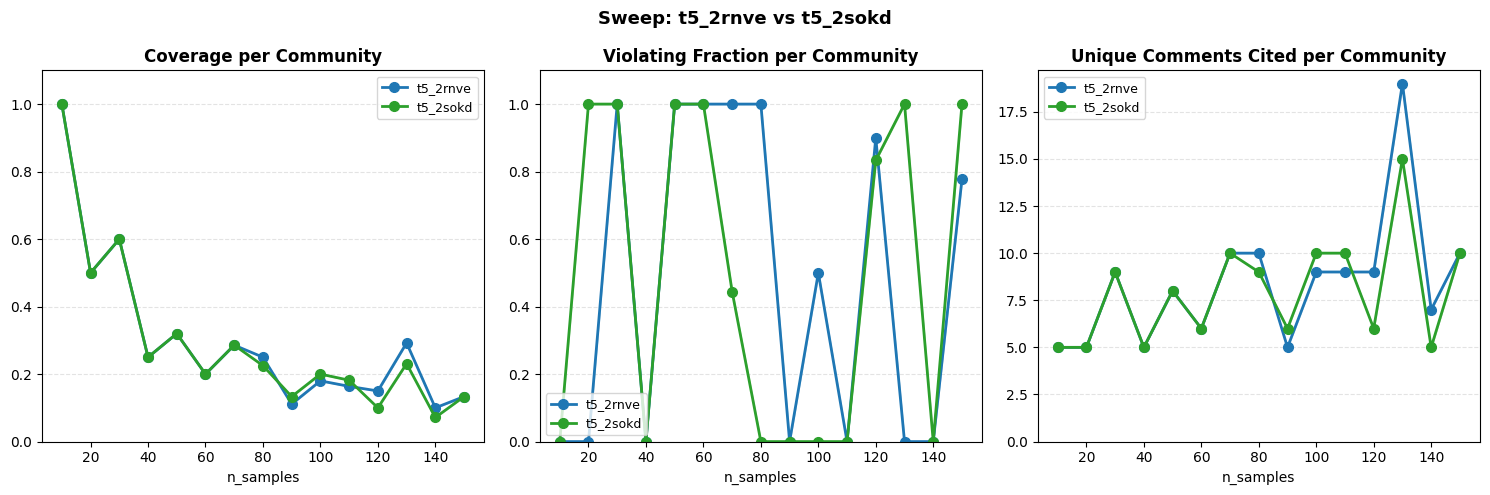

Sweep plot → 20260526_012902/sweep_20260526_012902.png
Sweep data → 20260526_012902/sweep_records_20260526_012902.json


In [37]:
COMMUNITY_A = "t5_2rnve"
COMMUNITY_B = "t5_2sokd"
DATA_FILE   = "../data_training_selected_clusters_comments_and_rules.csv"
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = Path(f"{timestamp}")

OUTPUT_DIR.mkdir(exist_ok=True)

analyzer = CommunityNormAnalyzer()
df = analyzer.load_data(DATA_FILE, min_samp=10)
df = df[df['community_id'].isin([COMMUNITY_A, COMMUNITY_B])]

for cid in [COMMUNITY_A, COMMUNITY_B]:
    n = len(df[df['community_id'] == cid])


RUN_SWEEP    = True
SWEEP_SIZES  = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
SWEEP_TRIALS = 1
if RUN_SWEEP:
    sweep_records = []
    _real_input = builtins.input
    builtins.input = lambda _prompt="": "sweep"

    try:
        for n in SWEEP_SIZES:
            for trial in range(SWEEP_TRIALS):
                random.seed(trial * 100)
                print(f"n={n}, trial={trial+1}/{SWEEP_TRIALS}")
                try:
                    r = analyzer.run_task(df, COMMUNITY_A, COMMUNITY_B,
                                         task_name="task2", n_samples=n, verbose=False)

                    if r and "error" not in r:
                        run_log_path = OUTPUT_DIR / "task2_run_log_all.json"
                        src = Path("task2_run_log.json")
                        if src.exists():
                            with open(src) as f:
                                run_log = json.load(f)
                            src.unlink()  # delete the original
                            if run_log_path.exists():
                                with open(run_log_path) as f:
                                    all_logs = json.load(f)
                            else:
                                all_logs = []
                            all_logs.append(run_log)
                            with open(run_log_path, 'w') as f:
                                json.dump(all_logs, f, indent=2, ensure_ascii=False)
                        rec = r['metrics'].copy()
                        rec['n_samples'] = n

                        # Per-community violating fractions
                        id_to_status = {c[0]: c[3] for c in r['input_comments']}
                        id_to_comm   = {c[0]: c[2] for c in r['input_comments']}
                        parsed = r['norms']

                        def vf_for(ids, community):
                            cited = [i for i in ids if id_to_comm.get(i) == community]
                            if not cited: return 0.0
                            return sum(1 for i in cited if id_to_status.get(i) == 'violation') / len(cited)

                        rec['violating_fraction_a'] = vf_for(parsed['comm_a_ids'], COMMUNITY_A)
                        rec['violating_fraction_b'] = vf_for(parsed['comm_b_ids'], COMMUNITY_B)
                        sweep_records.append(rec)
                        norms_log_path = OUTPUT_DIR / "norm_definitions_all.json"
                        # Load existing if present
                        if norms_log_path.exists():
                            with open(norms_log_path) as f:
                                all_norms = json.load(f)
                        else:
                            all_norms = []

                        all_norms.append({
                            "n_samples": n,
                            "trial": trial,
                            "community_a": COMMUNITY_A,
                            "community_b": COMMUNITY_B,
                            "norms": {
                                COMMUNITY_A: {"description": parsed['comm_a_desc'], "cited_ids": parsed['comm_a_ids']},
                                COMMUNITY_B: {"description": parsed['comm_b_desc'], "cited_ids": parsed['comm_b_ids']}
                            }
                        })

                        with open(norms_log_path, 'w') as f:
                            json.dump(all_norms, f, indent=2, ensure_ascii=False)
                        print(f"  cov={rec.get('coverage',0):.3f}  vf_a={rec['violating_fraction_a']:.3f}  vf_b={rec['violating_fraction_b']:.3f}")
                except NotEnoughSamplesError as e:
                    print(f"  Skipped: {e} — stopping sweep, not enough samples beyond n={n}")
                    SWEEP_SIZES = [s for s in SWEEP_SIZES if s < n]
                    break
    finally:
        builtins.input = _real_input

    # Sweep plots
    palette = plt.cm.tab10.colors
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Sweep: {COMMUNITY_A} vs {COMMUNITY_B}", fontsize=13, fontweight='bold')

    # Coverage — one line per community
    ax = axes[0]
    for label, raw_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        for n in SWEEP_SIZES:
            vals = [r[raw_metric] / (n/2) for r in sweep_records if r['n_samples'] == n and raw_metric in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Coverage per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(0, 1.1); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)
 # Violating fraction — one line per community
    ax = axes[1]
    for label, a_metric, b_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', 'violating_fraction_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', 'violating_fraction_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        vf_key = 'violating_fraction_a' if label == COMMUNITY_A else 'violating_fraction_b'
        for n in SWEEP_SIZES:
            vals = [r[vf_key] for r in sweep_records if r['n_samples'] == n and vf_key in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Violating Fraction per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(0, 1.1); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)

    # Unique comments — one line per community
    ax = axes[2]
    for label, raw_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        for n in SWEEP_SIZES:
            vals = [r[raw_metric] for r in sweep_records if r['n_samples'] == n and raw_metric in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Unique Comments Cited per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(bottom=0); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)

    plt.tight_layout()
    sweep_path = OUTPUT_DIR / f"sweep_{timestamp}.png"
    fig.savefig(sweep_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Sweep plot → {sweep_path}")

    sweep_json = OUTPUT_DIR / f"sweep_records_{timestamp}.json"
    with open(sweep_json, 'w') as f:
        json.dump(sweep_records, f, indent=2, ensure_ascii=False)
    print(f"Sweep data → {sweep_json}")
else:
    print("Sweep skipped — set RUN_SWEEP = True to enable.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1715.81it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


label
non_violation    17506
violation        15460
Name: count, dtype: int64
str
0         violation
1     non_violation
2     non_violation
3     non_violation
4         violation
5     non_violation
6     non_violation
7         violation
8     non_violation
9         violation
10        violation
11        violation
12        violation
13    non_violation
14    non_violation
15        violation
16        violation
17        violation
18        violation
19        violation
Name: label, dtype: str
Per-community counts (before filtering):
              violations  non_violations
community_id                            
t5_10qj6b             61              91
t5_10to4u              4               6
t5_1136aw              2               3
t5_11d8d1              2               0
t5_12n5pd              7              10
...                  ...             ...
t5_xa0lk               1               1
t5_xmk1t               2               2
t5_xpfq5               2               2
t5

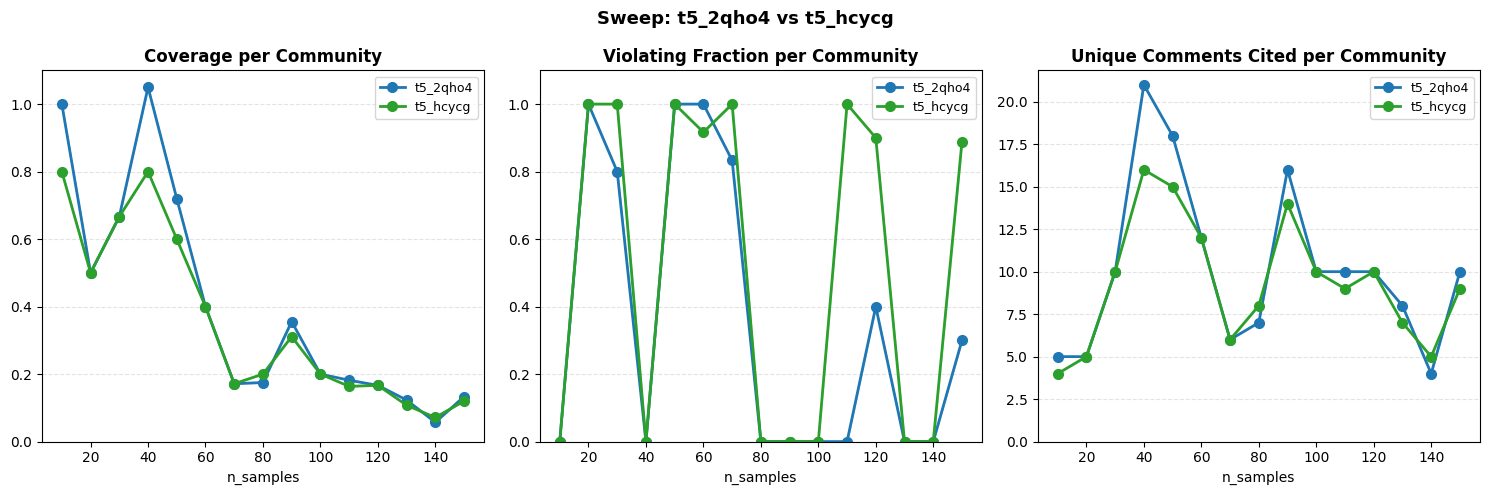

Sweep plot → 20260526_013330/sweep_20260526_013330.png
Sweep data → 20260526_013330/sweep_records_20260526_013330.json


In [38]:
COMMUNITY_A = "t5_2qho4"
COMMUNITY_B = "t5_hcycg"
DATA_FILE   = "../data_training_selected_clusters_comments_and_rules.csv"
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = Path(f"{timestamp}")

OUTPUT_DIR.mkdir(exist_ok=True)

analyzer = CommunityNormAnalyzer()
df = analyzer.load_data(DATA_FILE, min_samp=10)
df = df[df['community_id'].isin([COMMUNITY_A, COMMUNITY_B])]

for cid in [COMMUNITY_A, COMMUNITY_B]:
    n = len(df[df['community_id'] == cid])


RUN_SWEEP    = True
SWEEP_SIZES  = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
SWEEP_TRIALS = 1
if RUN_SWEEP:
    sweep_records = []
    _real_input = builtins.input
    builtins.input = lambda _prompt="": "sweep"

    try:
        for n in SWEEP_SIZES:
            for trial in range(SWEEP_TRIALS):
                random.seed(trial * 100)
                print(f"n={n}, trial={trial+1}/{SWEEP_TRIALS}")
                try:
                    r = analyzer.run_task(df, COMMUNITY_A, COMMUNITY_B,
                                         task_name="task2", n_samples=n, verbose=False)

                    if r and "error" not in r:
                        run_log_path = OUTPUT_DIR / "task2_run_log_all.json"
                        src = Path("task2_run_log.json")
                        if src.exists():
                            with open(src) as f:
                                run_log = json.load(f)
                            src.unlink()  # delete the original
                            if run_log_path.exists():
                                with open(run_log_path) as f:
                                    all_logs = json.load(f)
                            else:
                                all_logs = []
                            all_logs.append(run_log)
                            with open(run_log_path, 'w') as f:
                                json.dump(all_logs, f, indent=2, ensure_ascii=False)
                        rec = r['metrics'].copy()
                        rec['n_samples'] = n

                        # Per-community violating fractions
                        id_to_status = {c[0]: c[3] for c in r['input_comments']}
                        id_to_comm   = {c[0]: c[2] for c in r['input_comments']}
                        parsed = r['norms']

                        def vf_for(ids, community):
                            cited = [i for i in ids if id_to_comm.get(i) == community]
                            if not cited: return 0.0
                            return sum(1 for i in cited if id_to_status.get(i) == 'violation') / len(cited)

                        rec['violating_fraction_a'] = vf_for(parsed['comm_a_ids'], COMMUNITY_A)
                        rec['violating_fraction_b'] = vf_for(parsed['comm_b_ids'], COMMUNITY_B)
                        sweep_records.append(rec)
                        norms_log_path = OUTPUT_DIR / "norm_definitions_all.json"
                        # Load existing if present
                        if norms_log_path.exists():
                            with open(norms_log_path) as f:
                                all_norms = json.load(f)
                        else:
                            all_norms = []

                        all_norms.append({
                            "n_samples": n,
                            "trial": trial,
                            "community_a": COMMUNITY_A,
                            "community_b": COMMUNITY_B,
                            "norms": {
                                COMMUNITY_A: {"description": parsed['comm_a_desc'], "cited_ids": parsed['comm_a_ids']},
                                COMMUNITY_B: {"description": parsed['comm_b_desc'], "cited_ids": parsed['comm_b_ids']}
                            }
                        })

                        with open(norms_log_path, 'w') as f:
                            json.dump(all_norms, f, indent=2, ensure_ascii=False)
                        print(f"  cov={rec.get('coverage',0):.3f}  vf_a={rec['violating_fraction_a']:.3f}  vf_b={rec['violating_fraction_b']:.3f}")
                except NotEnoughSamplesError as e:
                    print(f"  Skipped: {e} — stopping sweep, not enough samples beyond n={n}")
                    SWEEP_SIZES = [s for s in SWEEP_SIZES if s < n]
                    break
    finally:
        builtins.input = _real_input

    # Sweep plots
    palette = plt.cm.tab10.colors
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Sweep: {COMMUNITY_A} vs {COMMUNITY_B}", fontsize=13, fontweight='bold')

    # Coverage — one line per community
    ax = axes[0]
    for label, raw_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        for n in SWEEP_SIZES:
            vals = [r[raw_metric] / (n/2) for r in sweep_records if r['n_samples'] == n and raw_metric in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Coverage per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(0, 1.1); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)
 # Violating fraction — one line per community
    ax = axes[1]
    for label, a_metric, b_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', 'violating_fraction_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', 'violating_fraction_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        vf_key = 'violating_fraction_a' if label == COMMUNITY_A else 'violating_fraction_b'
        for n in SWEEP_SIZES:
            vals = [r[vf_key] for r in sweep_records if r['n_samples'] == n and vf_key in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Violating Fraction per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(0, 1.1); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)

    # Unique comments — one line per community
    ax = axes[2]
    for label, raw_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        for n in SWEEP_SIZES:
            vals = [r[raw_metric] for r in sweep_records if r['n_samples'] == n and raw_metric in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Unique Comments Cited per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(bottom=0); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)

    plt.tight_layout()
    sweep_path = OUTPUT_DIR / f"sweep_{timestamp}.png"
    fig.savefig(sweep_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Sweep plot → {sweep_path}")

    sweep_json = OUTPUT_DIR / f"sweep_records_{timestamp}.json"
    with open(sweep_json, 'w') as f:
        json.dump(sweep_records, f, indent=2, ensure_ascii=False)
    print(f"Sweep data → {sweep_json}")
else:
    print("Sweep skipped — set RUN_SWEEP = True to enable.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1755.40it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


label
non_violation    17506
violation        15460
Name: count, dtype: int64
str
0         violation
1     non_violation
2     non_violation
3     non_violation
4         violation
5     non_violation
6     non_violation
7         violation
8     non_violation
9         violation
10        violation
11        violation
12        violation
13    non_violation
14    non_violation
15        violation
16        violation
17        violation
18        violation
19        violation
Name: label, dtype: str
Per-community counts (before filtering):
              violations  non_violations
community_id                            
t5_10qj6b             61              91
t5_10to4u              4               6
t5_1136aw              2               3
t5_11d8d1              2               0
t5_12n5pd              7              10
...                  ...             ...
t5_xa0lk               1               1
t5_xmk1t               2               2
t5_xpfq5               2               2
t5

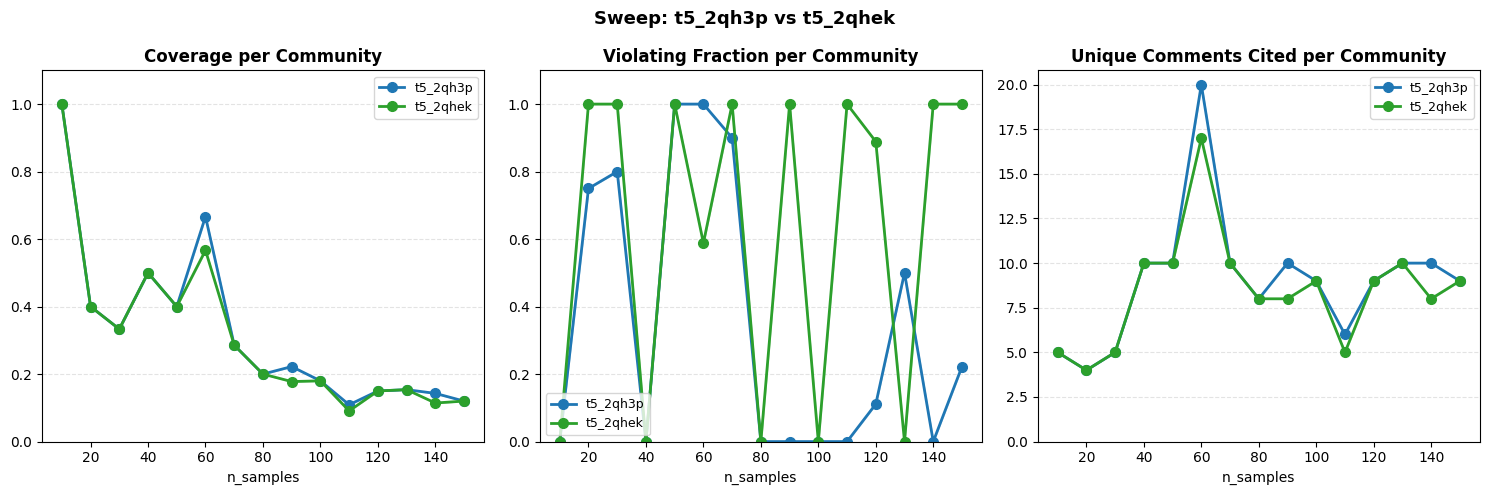

Sweep plot → 20260526_013757/sweep_20260526_013757.png
Sweep data → 20260526_013757/sweep_records_20260526_013757.json


In [39]:
COMMUNITY_A = "t5_2qh3p"
COMMUNITY_B = "t5_2qhek"
DATA_FILE   = "../data_training_selected_clusters_comments_and_rules.csv"
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = Path(f"{timestamp}")

OUTPUT_DIR.mkdir(exist_ok=True)

analyzer = CommunityNormAnalyzer()
df = analyzer.load_data(DATA_FILE, min_samp=10)
df = df[df['community_id'].isin([COMMUNITY_A, COMMUNITY_B])]

for cid in [COMMUNITY_A, COMMUNITY_B]:
    n = len(df[df['community_id'] == cid])


RUN_SWEEP    = True
SWEEP_SIZES  = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
SWEEP_TRIALS = 1
if RUN_SWEEP:
    sweep_records = []
    _real_input = builtins.input
    builtins.input = lambda _prompt="": "sweep"

    try:
        for n in SWEEP_SIZES:
            for trial in range(SWEEP_TRIALS):
                random.seed(trial * 100)
                print(f"n={n}, trial={trial+1}/{SWEEP_TRIALS}")
                try:
                    r = analyzer.run_task(df, COMMUNITY_A, COMMUNITY_B,
                                         task_name="task2", n_samples=n, verbose=False)

                    if r and "error" not in r:
                        run_log_path = OUTPUT_DIR / "task2_run_log_all.json"
                        src = Path("task2_run_log.json")
                        if src.exists():
                            with open(src) as f:
                                run_log = json.load(f)
                            src.unlink()  # delete the original
                            if run_log_path.exists():
                                with open(run_log_path) as f:
                                    all_logs = json.load(f)
                            else:
                                all_logs = []
                            all_logs.append(run_log)
                            with open(run_log_path, 'w') as f:
                                json.dump(all_logs, f, indent=2, ensure_ascii=False)
                        rec = r['metrics'].copy()
                        rec['n_samples'] = n

                        # Per-community violating fractions
                        id_to_status = {c[0]: c[3] for c in r['input_comments']}
                        id_to_comm   = {c[0]: c[2] for c in r['input_comments']}
                        parsed = r['norms']

                        def vf_for(ids, community):
                            cited = [i for i in ids if id_to_comm.get(i) == community]
                            if not cited: return 0.0
                            return sum(1 for i in cited if id_to_status.get(i) == 'violation') / len(cited)

                        rec['violating_fraction_a'] = vf_for(parsed['comm_a_ids'], COMMUNITY_A)
                        rec['violating_fraction_b'] = vf_for(parsed['comm_b_ids'], COMMUNITY_B)
                        sweep_records.append(rec)
                        norms_log_path = OUTPUT_DIR / "norm_definitions_all.json"
                        # Load existing if present
                        if norms_log_path.exists():
                            with open(norms_log_path) as f:
                                all_norms = json.load(f)
                        else:
                            all_norms = []

                        all_norms.append({
                            "n_samples": n,
                            "trial": trial,
                            "community_a": COMMUNITY_A,
                            "community_b": COMMUNITY_B,
                            "norms": {
                                COMMUNITY_A: {"description": parsed['comm_a_desc'], "cited_ids": parsed['comm_a_ids']},
                                COMMUNITY_B: {"description": parsed['comm_b_desc'], "cited_ids": parsed['comm_b_ids']}
                            }
                        })

                        with open(norms_log_path, 'w') as f:
                            json.dump(all_norms, f, indent=2, ensure_ascii=False)
                        print(f"  cov={rec.get('coverage',0):.3f}  vf_a={rec['violating_fraction_a']:.3f}  vf_b={rec['violating_fraction_b']:.3f}")
                except NotEnoughSamplesError as e:
                    print(f"  Skipped: {e} — stopping sweep, not enough samples beyond n={n}")
                    SWEEP_SIZES = [s for s in SWEEP_SIZES if s < n]
                    break
    finally:
        builtins.input = _real_input

    # Sweep plots
    palette = plt.cm.tab10.colors
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Sweep: {COMMUNITY_A} vs {COMMUNITY_B}", fontsize=13, fontweight='bold')

    # Coverage — one line per community
    ax = axes[0]
    for label, raw_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        for n in SWEEP_SIZES:
            vals = [r[raw_metric] / (n/2) for r in sweep_records if r['n_samples'] == n and raw_metric in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Coverage per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(0, 1.1); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)
 # Violating fraction — one line per community
    ax = axes[1]
    for label, a_metric, b_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', 'violating_fraction_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', 'violating_fraction_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        vf_key = 'violating_fraction_a' if label == COMMUNITY_A else 'violating_fraction_b'
        for n in SWEEP_SIZES:
            vals = [r[vf_key] for r in sweep_records if r['n_samples'] == n and vf_key in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Violating Fraction per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(0, 1.1); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)

    # Unique comments — one line per community
    ax = axes[2]
    for label, raw_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        for n in SWEEP_SIZES:
            vals = [r[raw_metric] for r in sweep_records if r['n_samples'] == n and raw_metric in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Unique Comments Cited per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(bottom=0); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)

    plt.tight_layout()
    sweep_path = OUTPUT_DIR / f"sweep_{timestamp}.png"
    fig.savefig(sweep_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Sweep plot → {sweep_path}")

    sweep_json = OUTPUT_DIR / f"sweep_records_{timestamp}.json"
    with open(sweep_json, 'w') as f:
        json.dump(sweep_records, f, indent=2, ensure_ascii=False)
    print(f"Sweep data → {sweep_json}")
else:
    print("Sweep skipped — set RUN_SWEEP = True to enable.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1760.96it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


label
non_violation    17506
violation        15460
Name: count, dtype: int64
str
0         violation
1     non_violation
2     non_violation
3     non_violation
4         violation
5     non_violation
6     non_violation
7         violation
8     non_violation
9         violation
10        violation
11        violation
12        violation
13    non_violation
14    non_violation
15        violation
16        violation
17        violation
18        violation
19        violation
Name: label, dtype: str
Per-community counts (before filtering):
              violations  non_violations
community_id                            
t5_10qj6b             61              91
t5_10to4u              4               6
t5_1136aw              2               3
t5_11d8d1              2               0
t5_12n5pd              7              10
...                  ...             ...
t5_xa0lk               1               1
t5_xmk1t               2               2
t5_xpfq5               2               2
t5

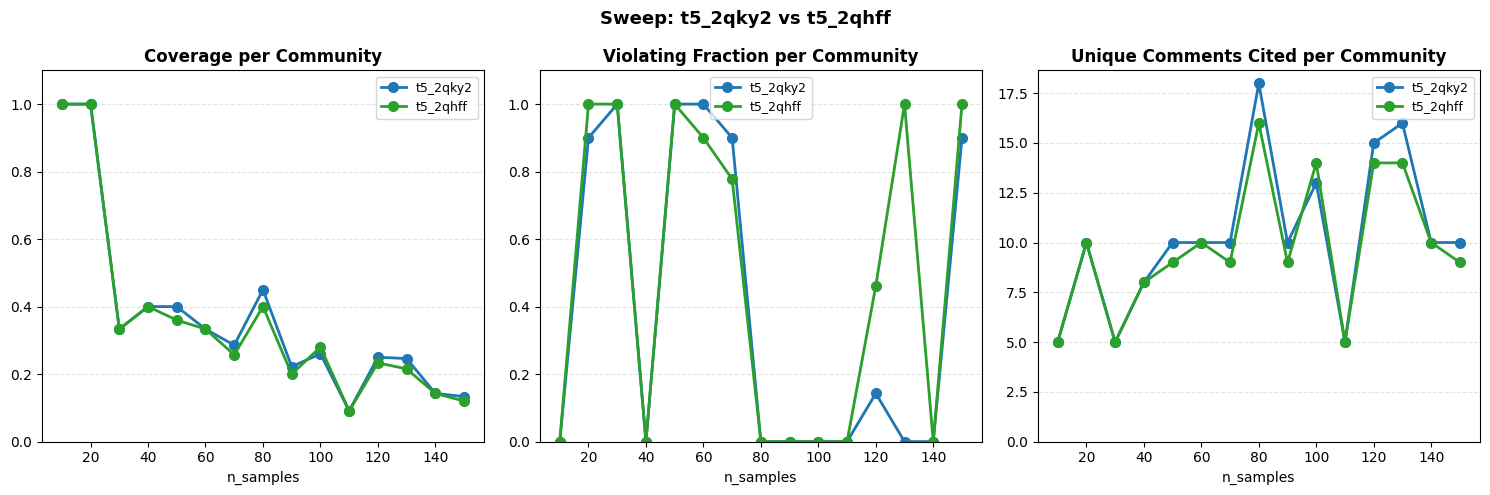

Sweep plot → 20260526_014245/sweep_20260526_014245.png
Sweep data → 20260526_014245/sweep_records_20260526_014245.json


In [40]:
COMMUNITY_A = "t5_2qky2"
COMMUNITY_B = "t5_2qhff"
DATA_FILE   = "../data_training_selected_clusters_comments_and_rules.csv"
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = Path(f"{timestamp}")

OUTPUT_DIR.mkdir(exist_ok=True)

analyzer = CommunityNormAnalyzer()
df = analyzer.load_data(DATA_FILE, min_samp=10)
df = df[df['community_id'].isin([COMMUNITY_A, COMMUNITY_B])]

for cid in [COMMUNITY_A, COMMUNITY_B]:
    n = len(df[df['community_id'] == cid])


RUN_SWEEP    = True
SWEEP_SIZES  = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
SWEEP_TRIALS = 1
if RUN_SWEEP:
    sweep_records = []
    _real_input = builtins.input
    builtins.input = lambda _prompt="": "sweep"

    try:
        for n in SWEEP_SIZES:
            for trial in range(SWEEP_TRIALS):
                random.seed(trial * 100)
                print(f"n={n}, trial={trial+1}/{SWEEP_TRIALS}")
                try:
                    r = analyzer.run_task(df, COMMUNITY_A, COMMUNITY_B,
                                         task_name="task2", n_samples=n, verbose=False)

                    if r and "error" not in r:
                        run_log_path = OUTPUT_DIR / "task2_run_log_all.json"
                        src = Path("task2_run_log.json")
                        if src.exists():
                            with open(src) as f:
                                run_log = json.load(f)
                            src.unlink()  # delete the original
                            if run_log_path.exists():
                                with open(run_log_path) as f:
                                    all_logs = json.load(f)
                            else:
                                all_logs = []
                            all_logs.append(run_log)
                            with open(run_log_path, 'w') as f:
                                json.dump(all_logs, f, indent=2, ensure_ascii=False)
                        rec = r['metrics'].copy()
                        rec['n_samples'] = n

                        # Per-community violating fractions
                        id_to_status = {c[0]: c[3] for c in r['input_comments']}
                        id_to_comm   = {c[0]: c[2] for c in r['input_comments']}
                        parsed = r['norms']

                        def vf_for(ids, community):
                            cited = [i for i in ids if id_to_comm.get(i) == community]
                            if not cited: return 0.0
                            return sum(1 for i in cited if id_to_status.get(i) == 'violation') / len(cited)

                        rec['violating_fraction_a'] = vf_for(parsed['comm_a_ids'], COMMUNITY_A)
                        rec['violating_fraction_b'] = vf_for(parsed['comm_b_ids'], COMMUNITY_B)
                        sweep_records.append(rec)
                        norms_log_path = OUTPUT_DIR / "norm_definitions_all.json"
                        # Load existing if present
                        if norms_log_path.exists():
                            with open(norms_log_path) as f:
                                all_norms = json.load(f)
                        else:
                            all_norms = []

                        all_norms.append({
                            "n_samples": n,
                            "trial": trial,
                            "community_a": COMMUNITY_A,
                            "community_b": COMMUNITY_B,
                            "norms": {
                                COMMUNITY_A: {"description": parsed['comm_a_desc'], "cited_ids": parsed['comm_a_ids']},
                                COMMUNITY_B: {"description": parsed['comm_b_desc'], "cited_ids": parsed['comm_b_ids']}
                            }
                        })

                        with open(norms_log_path, 'w') as f:
                            json.dump(all_norms, f, indent=2, ensure_ascii=False)
                        print(f"  cov={rec.get('coverage',0):.3f}  vf_a={rec['violating_fraction_a']:.3f}  vf_b={rec['violating_fraction_b']:.3f}")
                except NotEnoughSamplesError as e:
                    print(f"  Skipped: {e} — stopping sweep, not enough samples beyond n={n}")
                    SWEEP_SIZES = [s for s in SWEEP_SIZES if s < n]
                    break
    finally:
        builtins.input = _real_input

    # Sweep plots
    palette = plt.cm.tab10.colors
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Sweep: {COMMUNITY_A} vs {COMMUNITY_B}", fontsize=13, fontweight='bold')

    # Coverage — one line per community
    ax = axes[0]
    for label, raw_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        for n in SWEEP_SIZES:
            vals = [r[raw_metric] / (n/2) for r in sweep_records if r['n_samples'] == n and raw_metric in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Coverage per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(0, 1.1); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)
 # Violating fraction — one line per community
    ax = axes[1]
    for label, a_metric, b_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', 'violating_fraction_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', 'violating_fraction_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        vf_key = 'violating_fraction_a' if label == COMMUNITY_A else 'violating_fraction_b'
        for n in SWEEP_SIZES:
            vals = [r[vf_key] for r in sweep_records if r['n_samples'] == n and vf_key in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Violating Fraction per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(0, 1.1); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)

    # Unique comments — one line per community
    ax = axes[2]
    for label, raw_metric, color in [
        (COMMUNITY_A, 'unique_comments_a', palette[0]),
        (COMMUNITY_B, 'unique_comments_b', palette[2]),
    ]:
        xs, ys, ys_s = [], [], []
        for n in SWEEP_SIZES:
            vals = [r[raw_metric] for r in sweep_records if r['n_samples'] == n and raw_metric in r]
            if vals: xs.append(n); ys.append(np.mean(vals)); ys_s.append(np.std(vals))
        if xs:
            ys, ys_s = np.array(ys), np.array(ys_s)
            ax.fill_between(xs, ys-ys_s, ys+ys_s, color=color, alpha=0.18)
            ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7, label=label)
    ax.set_title('Unique Comments Cited per Community', fontweight='bold'); ax.set_xlabel('n_samples')
    ax.set_ylim(bottom=0); ax.legend(fontsize=9); ax.grid(axis='y', linestyle='--', alpha=0.35)

    plt.tight_layout()
    sweep_path = OUTPUT_DIR / f"sweep_{timestamp}.png"
    fig.savefig(sweep_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Sweep plot → {sweep_path}")

    sweep_json = OUTPUT_DIR / f"sweep_records_{timestamp}.json"
    with open(sweep_json, 'w') as f:
        json.dump(sweep_records, f, indent=2, ensure_ascii=False)
    print(f"Sweep data → {sweep_json}")
else:
    print("Sweep skipped — set RUN_SWEEP = True to enable.")